In [ ]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [ ]:
data = pd.read_csv('/content/odor_dataset_final.csv')
data.head()

,Ethanol,Isopropyl Alcohol,Methanol,Butane,Propane,Isobutane,Dimethyl Ether,Formaldehyde,Benzaldehyde,Cinnamaldehyde,Acetone,Musk Ketone,Ethyl Acetate,Amyl Acetate,Toluene,Xylene,Class
0,23.59,10.98,17.04,15.69,9.02,10.23,1.04,13.55,4.70,9.03,5.87,9.94,10.11,2.44,7.16,11.61,Alcoholic
1,11.12,1.94,13.53,20.38,10.44,9.31,5.52,10.47,7.52,16.80,7.83,7.72,21.33,18.10,2.38,9.55,Fruity
2,10.24,3.76,12.50,16.63,9.45,6.75,2.57,12.07,8.51,19.49,10.95,11.47,17.23,21.84,4.89,10.11,Fruity
3,9.12,9.09,1.78,16.65,11.06,6.73,3.47,11.72,1.49,7.70,6.70,9.98,10.33,8.21,7.31,6.25,Gasoline-like
4,6.27,2.42,13.33,15.74,6.65,1.55,2.09,12.17,2.53,11.64,15.02,7.02,6.25,4.80,9.22,14.48,Chemical


In [ ]:
X = data.drop(columns=['Class'])
y = data['Class']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode new grouped labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42
)

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)
print("Classes:", le.classes_)


X shape: (4000, 16)
y shape: (4000, 5)
Classes: ['Alcoholic' 'Chemical' 'Fruity' 'Gasoline-like' 'Sweet']


In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.3,
    callbacks=[early_stop],
    verbose=1
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6100 - loss: 1.0674 - val_accuracy: 0.9542 - val_loss: 0.1315
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9356 - loss: 0.1949 - val_accuracy: 0.9567 - val_loss: 0.1283
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9282 - loss: 0.1938 - val_accuracy: 0.9600 - val_loss: 0.1188
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9452 - loss: 0.1569 - val_accuracy: 0.9575 - val_loss: 0.1217
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9320 - loss: 0.1833 - val_accuracy: 0.9567 - val_loss: 0.1292
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9404 - loss: 0.1624 - val_accuracy: 0.9633 - val_loss: 0.1244
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9416 - loss: 0.1454 - val_accuracy: 0.9533 - val_loss: 0.1540
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9531 - loss: 0.1613 - val_accuracy: 0.9550 - 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")



Test Loss: 0.1662
Test Accuracy: 0.9420


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


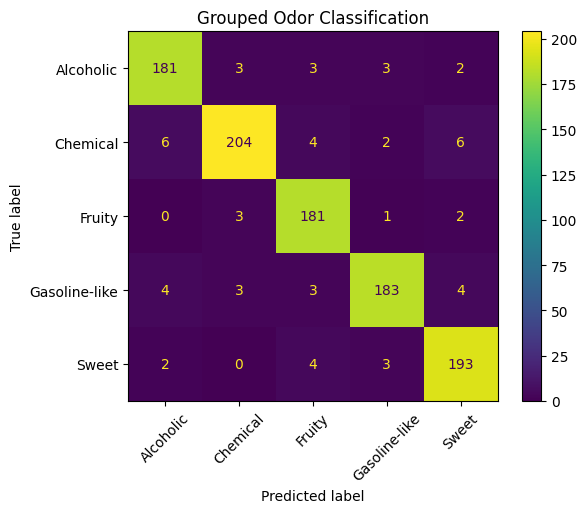

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Grouped Odor Classification")
plt.show()



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


<Figure size 800x600 with 0 Axes>

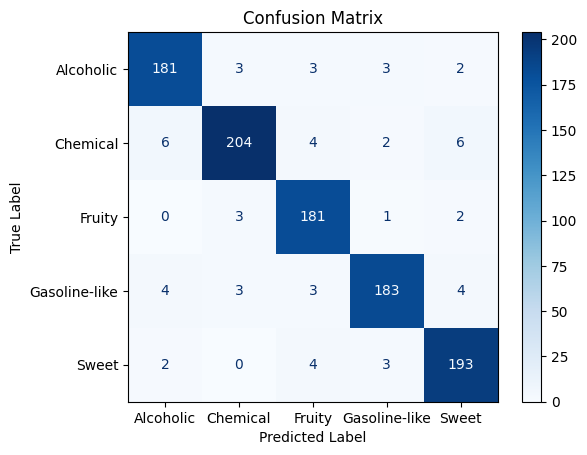

In [ ]:
# Predict on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict again if needed
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report (includes precision, recall, f1-score)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy:  {accuracy:.4f}")
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall:    {recall:.4f}")
print(f"Overall F1-score:  {f1:.4f}")

# Confusion Matrix and TP, FP, TN, FN
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# TP, FP, TN, FN for each class
print("\nPer-class TP, FP, TN, FN:")

for i, class_name in enumerate(le.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(f"\nClass: {class_name}")
    print(f"True Positives:  {TP}")
    print(f"False Positives: {FP}")
    print(f"False Negatives: {FN}")
    print(f"True Negatives:  {TN}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:

               precision    recall  f1-score   support

    Alcoholic       0.94      0.94      0.94       192
     Chemical       0.96      0.92      0.94       222
       Fruity       0.93      0.97      0.95       187
Gasoline-like       0.95      0.93      0.94       197
        Sweet       0.93      0.96      0.94       202

     accuracy                           0.94      1000
    macro avg       0.94      0.94      0.94      1000
 weighted avg       0.94      0.94      0.94      1000

Overall Accuracy:  0.9420
Overall Precision: 0.9424
Overall Recall:    0.9420
Overall F1-score:  0.9420

Confusion Matrix:
 [[181   3   3   3   2]
 [  6 204   4   2   6]
 [  0   3 181   1   2]
 [  4   3   3 183   4]
 [  2   0   4   3 193]]

Per-class TP, FP, TN, FN:

Class: Alcoholic
True Positives:  181
False Positives: 12
False Negatives: 11
True Negatives:  796

Class: Chemical
True Positives:  204
False Positives: 9
False Negatives